# What does crash insurance actually cost? ☂️
### TAIL, the fund that buys the puts everyone else sells — in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2020 win kept?: Busted](https://img.shields.io/badge/2020_win_kept%3F-Busted-8b949e?style=flat-square)

There is an ETF whose whole job is to protect you from a market crash. It's called **TAIL**: roughly 90% safe US Treasury bonds plus a steady budget of deep out-of-the-money **put options** on the S&P 500 — lottery tickets that pay off when the market falls hard. It launched in April 2017, it did **exactly what its prospectus promised** — and a dollar invested at launch is worth about **50 cents** today.

That's not a scandal. That's the **price of insurance**, quoted in public, every day. This study measures the bill precisely — and shows the same money landing in the pocket of the desk's short-volatility studies ([92-easy-money](../../92-easy-money/), [63-free-fall](../../63-free-fall/)), which sit on the *other side* of this exact trade.

> 📓 **Plain-language layer.** Want the *t*-stats, the regression and the variance arithmetic? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it from cached real data (as-of 2026-06-30); house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crash_insurance_cost import data, strategy as st

HAVE_REAL = data.have_real()
TAPE = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| rows:", 0 if TAPE is None else len(TAPE))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': 'c3658cfa4e95', 'start': '2017-04-06', 'end': '2026-06-30', 'years': 9.2, 'n_days': 2319, 'n_months': 110, 'total_pct': -49.7, 'cagr_pct': -7.17, 'vol_pct': 14.8, 'daily_bps': -2.53, 'daily_t': -1.49, 'monthly_bps': -56.52, 'monthly_t': -2.17, 'alpha_d_bps': -3.08, 'alpha_d_ann': -7.75, 'alpha_d_t': -1.98, 'beta_d': 1.05, 'r2_d': 0.226, 'alpha_m_bps': -64.09, 'alpha_m_ann': -7.69, 'alpha_m_t': -3.28, 'beta_m': 0.73, 'pre_ann': -14.7, 'pre_t': -2.5, 'post_ann': -8.07, 'post_t': -1.75, 'covid_gain': 28.47, 'covid_peak': '2020-04-02', 'spy_fall': -33.72, 'giveback': '2021-03-05', 'giveback_days': 337, 'holder_peak': 4.22, 'holder_now': -49.67, 'vrp_start': '1993-02', 'vrp_end': '2026-06', 'vrp_months': 401, 'vrp_var': -0.95, 'vrp_var_t': -3.12, 'vrp_vol': -3.79, 'vrp_vol_t': -9.42, 'vrp_win': 16.2, 'iv': 20.98, 'rv': 18.58, 'vrp_era_var': -0.67, 'vrp_era_var_t': -1.06, 'vrp_era_vol': -3.62, 'vrp_era_vol_t': -4.44, 'n_cohorts': 110, 'ahead_now': 1, 'ahead_share': 0.9, 'best': 0.1, 'best_date': '2025-01-31', 'median': -34.1, 'worst': -49.4, 'ever_ahead': 71.8, 'blends': [(5, 14.06, 15.12, 1.06, -22.9, -23.9, -17.6, -19.4), (10, 12.99, 15.12, 2.13, -21.9, -23.9, -15.8, -19.4), (20, 10.84, 15.12, 4.28, -19.9, -23.9, -12.1, -19.4)], 'ctrl': [(0.0, -0.21, -0.31, 5.0), (5.0, -5.21, -5.81, 100.0)]}


real cache present: True | rows: 9191


## The answer first

| Question | Answer |
|---|---|
| Does crash insurance really bleed every year? | **Yes — measurably.** TAIL has lost **-7.2% a year** since 2017 (-50% in total), and about **8% a year** of that is the *insurance itself* (the puts + the fee), not its bonds. Statistically solid, not bad luck. |
| But didn't it pay off in 2020? | **Spectacularly — for 337 days.** It jumped **+28%** while the market fell a third… and by March 2021 the entire jackpot was gone. |
| Did *anyone* who bought it come out ahead? | **Essentially no.** Of 110 possible monthly entry points since launch, **1** is above water today (by +0.1%, bought in 2025 — *after* the crash). |
| Where does the money go? | To the **sellers** of the insurance. Option markets consistently price volatility ~2.4 points higher than what the market then delivers — that gap is the *volatility risk premium*, and the buyer pays it in 5 months out of 6. |

> Crash insurance isn't broken — it's **expensive, and priced to be**. The claim is true, and the money is real: it just flows the other way.

## 1 · The claim

> *"Tail-risk funds and put-buying strategies bleed money every single year. The bleed isn't a flaw — it IS the volatility risk premium, seen from the buyer's side."*

Insurance intuition says this should be true: home insurers profit, so homeowners — in aggregate — pay more than they collect. The market version: people *really* dislike crashes, so crash protection trades **above** its actuarial value, permanently. Academics have measured it for decades (options that protect are the most reliably 'overpriced' instruments in finance). TAIL is the rare **live, buyable, fee-charging** version — the cleanest public quote of what the insurance costs.

## 2 · So what?

Millions of investors hold a slice of "tail protection" because the 2020-spike chart is the best marketing image in finance. If the bleed is real and large, that slice quietly costs several percent **per year** — far more than the crash relief is worth to most portfolios. And if the bleed *is* the volatility risk premium, then the desk's short-vol studies (92, 63 — both graded **Real**) and this fund are the two ends of one pipe: whatever TAIL's holders lose, volatility sellers collect.

## 3 · How would we even know?

Four measurements on real prices (2017-04-06 → 2026-06-30, dividends reinvested):

1. **The raw bill.** TAIL's total-return path since launch, with proper serial-correlation-robust statistics on the drift.
2. **The bill, itemised.** TAIL is ~90% Treasury bonds + puts. Compare it against **IEF** (the same bonds, without the puts): the gap is what the *insurance itself* costs — bond moves can't be blamed.
3. **The one payoff.** Quantify 2020 end-to-end: how big, how long it lasted, who kept it.
4. **Name the premium.** From the VIX (the market's quoted price of insurance) vs what the S&P actually delivered, month by month since 1993 — the insurance buyer's win/loss record.

## 4 · The teardown — let's actually look

**The whole story in one chart.** TAIL since launch, with the 2020 spike — and what happened after.

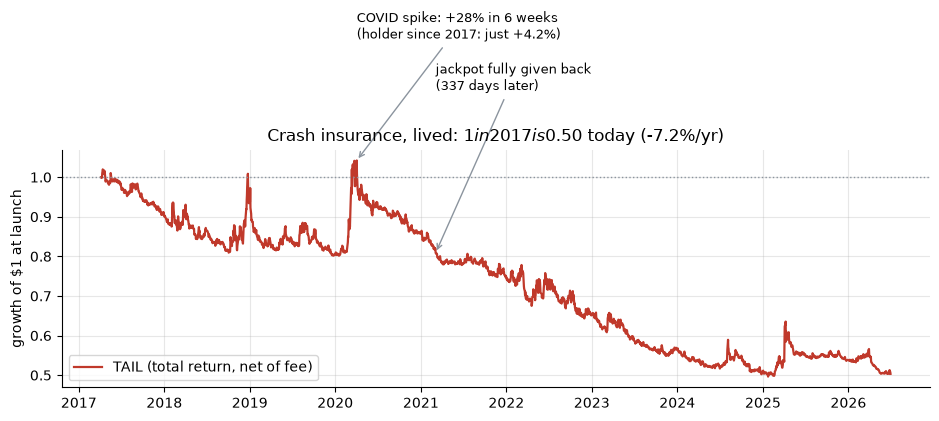

total -49.7%  CAGR -7.17%/yr  over 9.2 years


In [2]:
if HAVE_REAL:
    px = TAPE['tail'].dropna(); curve = px / px.iloc[0]
    fig, ax = plt.subplots()
    ax.plot(curve.index, curve.values, color=RED, lw=1.6, label='TAIL (total return, net of fee)')
    ax.axhline(1.0, color=GREY, ls=':', lw=1)
    peak = pd.Timestamp(R['covid_peak']); gb = pd.Timestamp(R['giveback'])
    ax.annotate(f"COVID spike: +{R['covid_gain']:.0f}% in 6 weeks\n(holder since 2017: just +{R['holder_peak']:.1f}%)",
                xy=(peak, float(curve.loc[:peak].iloc[-1])), xytext=(peak, 1.35),
                arrowprops=dict(arrowstyle='->', color=GREY), fontsize=9)
    ax.annotate(f"jackpot fully given back\n({R['giveback_days']} days later)",
                xy=(gb, float(curve.loc[:gb].iloc[-1])), xytext=(gb, 1.22),
                arrowprops=dict(arrowstyle='->', color=GREY), fontsize=9)
    ax.set_ylabel('growth of $1 at launch'); ax.legend(loc='lower left')
    ax.set_title(f"Crash insurance, lived: $1 in 2017 is ${float(curve.iloc[-1]):.2f} today ({R['cagr_pct']:.1f}%/yr)")
    plt.tight_layout(); plt.show()
    print(f'total {R["total_pct"]:.1f}%  CAGR {R["cagr_pct"]:.2f}%/yr  over {R["years"]:.1f} years')
else:
    print('cache missing - frozen numbers:', R['total_pct'], '% total,', R['cagr_pct'], '%/yr')

A dollar at launch is **50 cents** today: **-7.2%/yr** for 9 straight years, *including* the best crash payoff the fund will likely ever see. And the fund did nothing wrong — this is the product working as designed.

**Itemise the bill.** TAIL is mostly Treasury bonds. Strip the bond part out (compare against IEF, the same kind of bonds) and what's left is the pure cost of the puts + fee:

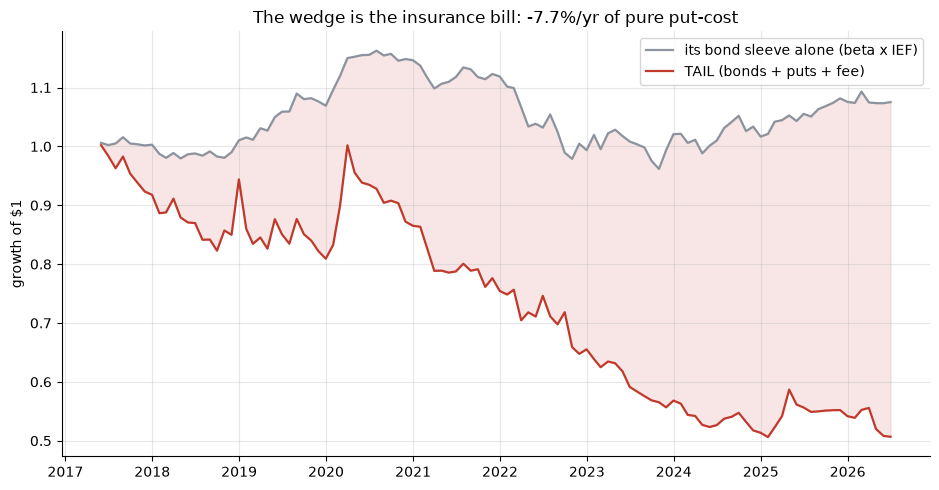

insurance bill: -7.69%/yr (monthly alpha vs IEF, HAC t = -3.28)


In [3]:
if HAVE_REAL:
    rets = st.to_returns(TAPE)
    dm = st.decompose_monthly(TAPE)
    # counterfactual: TAIL's bond sleeve alone (beta x IEF), vs actual TAIL
    m = (1.0 + rets).resample('ME').prod() - 1.0
    m = m.iloc[1:]
    bond_part = (1.0 + dm['beta_ief'] * m['ief']).cumprod()
    actual = (1.0 + m['tail']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(bond_part.index, bond_part.values, color=GREY, lw=1.6, label='its bond sleeve alone (beta x IEF)')
    ax.plot(actual.index, actual.values, color=RED, lw=1.6, label='TAIL (bonds + puts + fee)')
    ax.fill_between(actual.index, actual.values, bond_part.values, color=RED, alpha=.12)
    ax.set_ylabel('growth of $1'); ax.legend()
    ax.set_title(f"The wedge is the insurance bill: {dm['alpha_ann_pct']:.1f}%/yr of pure put-cost")
    plt.tight_layout(); plt.show()
    print(f"insurance bill: {dm['alpha_ann_pct']:.2f}%/yr (monthly alpha vs IEF, HAC t = {dm['t_alpha']:.2f})")
else:
    print('cache missing - frozen:', R['alpha_m_ann'], '%/yr, t =', R['alpha_m_t'])

The insurance itself — not the bonds — costs **≈8%/yr** (statistically solid: the quants notebook shows *t* = -3.3, and the bleed is there both before and after COVID). Of that, only 0.59 points is the management fee; the rest is the **put ladder burning down** month after month.

**Who ever came out ahead?** Take every possible monthly entry since launch and hold to today:

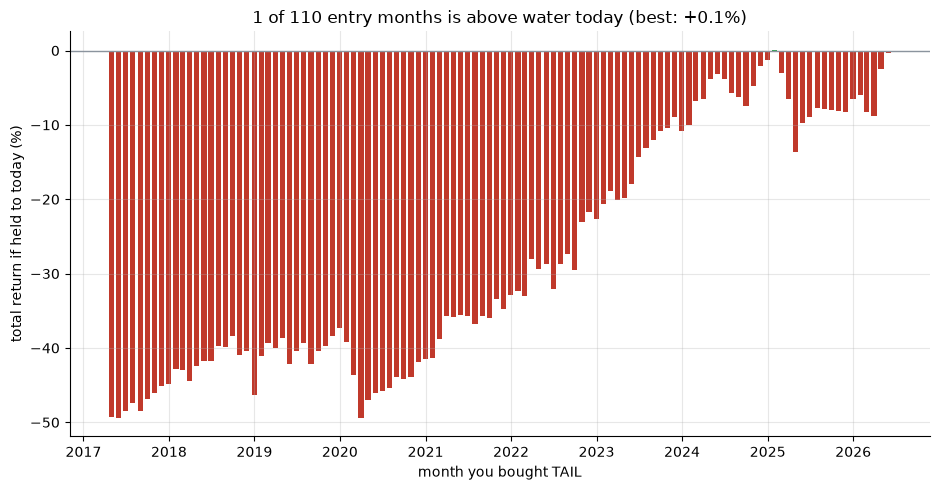

ahead today: 1/110  median -34.1%  ever-ahead along the way: 71.8%


In [4]:
if HAVE_REAL:
    co = st.cohort_table(TAPE)
    tot = co['cohort_returns'] * 100
    fig, ax = plt.subplots()
    colors = [GREEN if v > 0 else RED for v in tot.values]
    ax.bar(tot.index, tot.values, width=22, color=colors)
    ax.axhline(0, color=GREY, lw=1)
    ax.set_ylabel('total return if held to today (%)'); ax.set_xlabel('month you bought TAIL')
    ax.set_title(f"{co['n_ahead_now']} of {co['n_cohorts']} entry months is above water today (best: +{co['best_pct']:.1f}%)")
    plt.tight_layout(); plt.show()
    print(f"ahead today: {co['n_ahead_now']}/{co['n_cohorts']}  median {co['median_pct']:.1f}%  "
          f"ever-ahead along the way: {co['share_ever_ahead']:.1f}%")
else:
    print('cache missing - frozen:', R['ahead_now'], 'of', R['n_cohorts'], 'ahead; median', R['median'], '%')

A wall of red. **1 of 110** entry months is above water today — by **+0.1%**, and that buyer entered in *2025*, long after the crash. The twist: **72%** of buyers *were* ahead at some point — the 2020 spike lifted everyone who bought early — and every single one of them gave it back within a year. The insurance pays; holding it takes the payment back.

## 5 · The verdict

- **Signal — Real.** The bleed is genuine and statistically solid: **-7.2%/yr** overall, **≈8%/yr** of pure insurance cost once bonds are stripped out, and the market has priced insurance above what it delivers in 5 months out of 6 for 33 years. This is the volatility risk premium — from the paying side.
- **Tradability — Mirage** (for the buyer). There is nothing to deploy on the long side: every portfolio blend with TAIL lowered returns by 1–4+ points a year for a modest crash cushion, and the one jackpot evaporated in 337 days. The tradable side of this premium is the *seller's* — studies [92](../../92-easy-money/) and [63](../../63-free-fall/).
- **"The 2020 win made it worth it"? — Busted.** At the very top of the payoff, a day-one holder was up just **+4.2%** — the bleed had already eaten three years of gains — and 337 days later even that was gone.

## 6 · Going further 🚪

- **Insurance isn't supposed to be an investment.** A negative-carry hedge *can* be rational if it lets you hold more risk elsewhere — but then the honest accounting is the blend table (quants notebook §4d): here the crash cushion never repaid its annual bill.
- **The premium is the point.** The same gap that bleeds TAIL is what pays the short-vol carry the desk graded Real in [92-easy-money](../../92-easy-money/) and [63-free-fall](../../63-free-fall/) — and what the SKEW index *quotes* but doesn't predict ([86-tail-radar](../../86-tail-radar/)).
- **Timing is the only escape hatch** — buy the insurance only when it's cheap and crashes are near. That requires a crash signal; 86 tested the most famous one and found none.

*Think you can hold a −7.7%/yr bleed long enough to catch the next 2020 — and sell the spike within weeks? That's the only version of this trade that has ever worked on paper. Show it with an honest exit rule — then we'll talk.*